Following the data wrangling step, I have some immediate questions regarding the data: 
1. I'm confused as to the value of the campaign engagment metrics for this use case and what to explore possible relationships with the target (conversion variable) or to learn if these data points are droppable. 
2. I'll want to explore demographic and campaign based  groupings of the data. 
3. I need to start thinking of creative ways to use the data presented to me as I feel there is some inherent weirdness with AdSpend values for example -- is that total campaign spend? Am I supposed to believe that each customer ID had a separate campaign targeted at them? Clearly, that's the implication of the data? 

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r'C:\Users\ryan1\Desktop\Capstone Three\Capstone-Three\EDA\df2.csv')
df.head()

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,1


In [4]:
dtypes = df.dtypes.to_dict()
df.dtypes

CustomerID             int64
Age                    int64
Gender                object
Income                 int64
CampaignChannel       object
CampaignType          object
AdSpend              float64
ClickThroughRate     float64
ConversionRate       float64
WebsiteVisits          int64
PagesPerVisit        float64
TimeOnSite           float64
SocialShares           int64
EmailOpens             int64
EmailClicks            int64
PreviousPurchases      int64
LoyaltyPoints          int64
Conversion             int64
dtype: object

In [5]:
string_columns = []
float_columns = []
int_columns = []

for col, dtype in dtypes.items():
    if dtype == 'object':
        string_columns.append(col)
    elif dtype == 'float64':
        float_columns.append(col)
    elif dtype == 'int64':
        int_columns.append(col)
    else:
        pass
    print(f"Column: {col} categorized.")


Column: CustomerID categorized.
Column: Age categorized.
Column: Gender categorized.
Column: Income categorized.
Column: CampaignChannel categorized.
Column: CampaignType categorized.
Column: AdSpend categorized.
Column: ClickThroughRate categorized.
Column: ConversionRate categorized.
Column: WebsiteVisits categorized.
Column: PagesPerVisit categorized.
Column: TimeOnSite categorized.
Column: SocialShares categorized.
Column: EmailOpens categorized.
Column: EmailClicks categorized.
Column: PreviousPurchases categorized.
Column: LoyaltyPoints categorized.
Column: Conversion categorized.


In [6]:
df_no_string = df.drop(columns=string_columns)

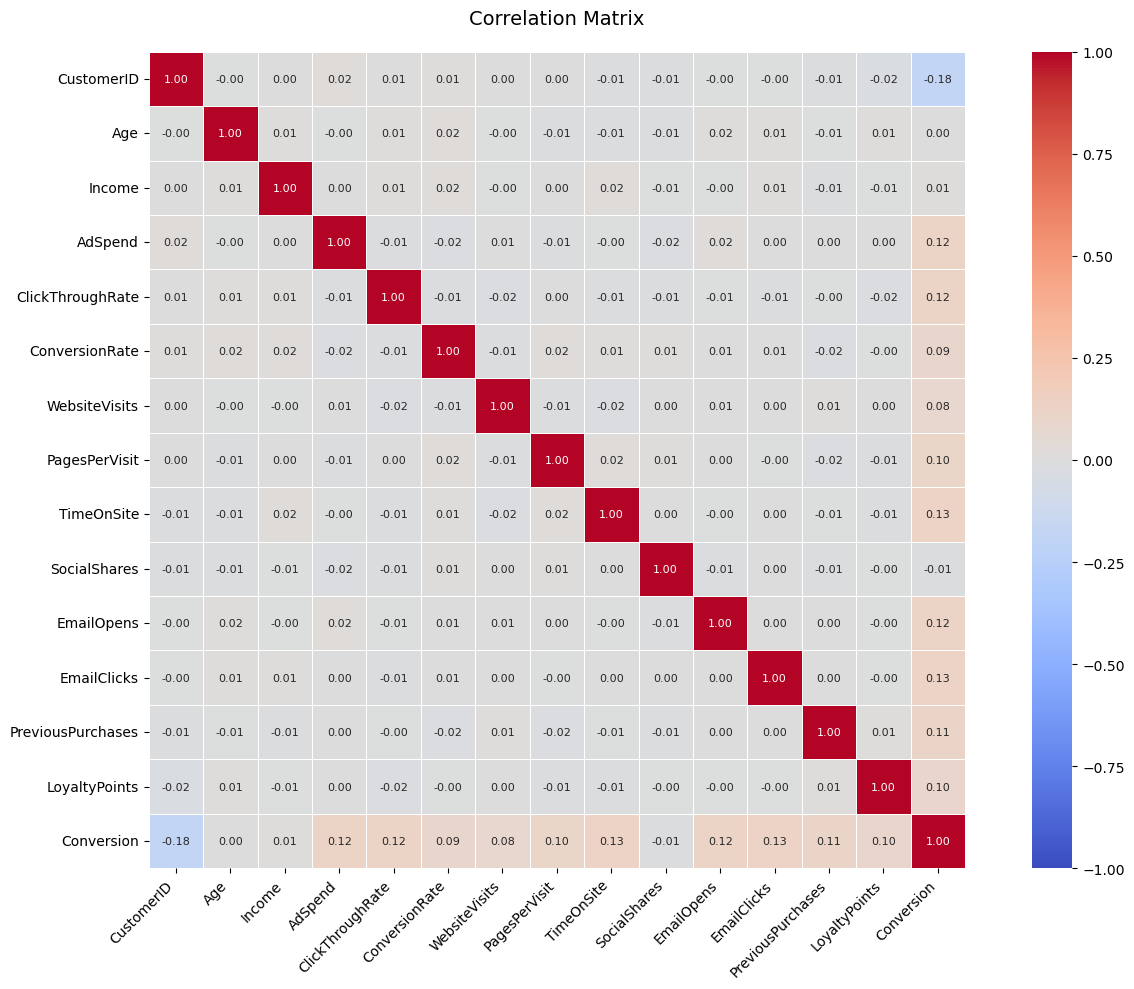

In [7]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_no_string.corr(),
    annot=True,
    fmt='.2f',            
    cmap='coolwarm',
    annot_kws={'size': 8}, 
    linewidths=0.5,
    vmin=-1, vmax=1,
    square=True
)
plt.title('Correlation Matrix', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

As uncovered in Data Wrangling, very little multicollinearity between x variables and it looks like weak correlations between most x and y variables. This problem might not easily lend itself to a simple PCA and log regression classification model. 

A little stange that their was a correlation between customerID and conversion at all, marginally concerning that it's actually one of the stronger correlations. This data may not be very informative. Particularly concerning that Conversion Rate and Conversion didn't see a strong correlation, were this data real we would expect thesse variables to move together somewhat since the occurence of a conversion should mathematically increase the conversion rate. 

Changing gears, I'm going to investigate correlations between categoricals. 

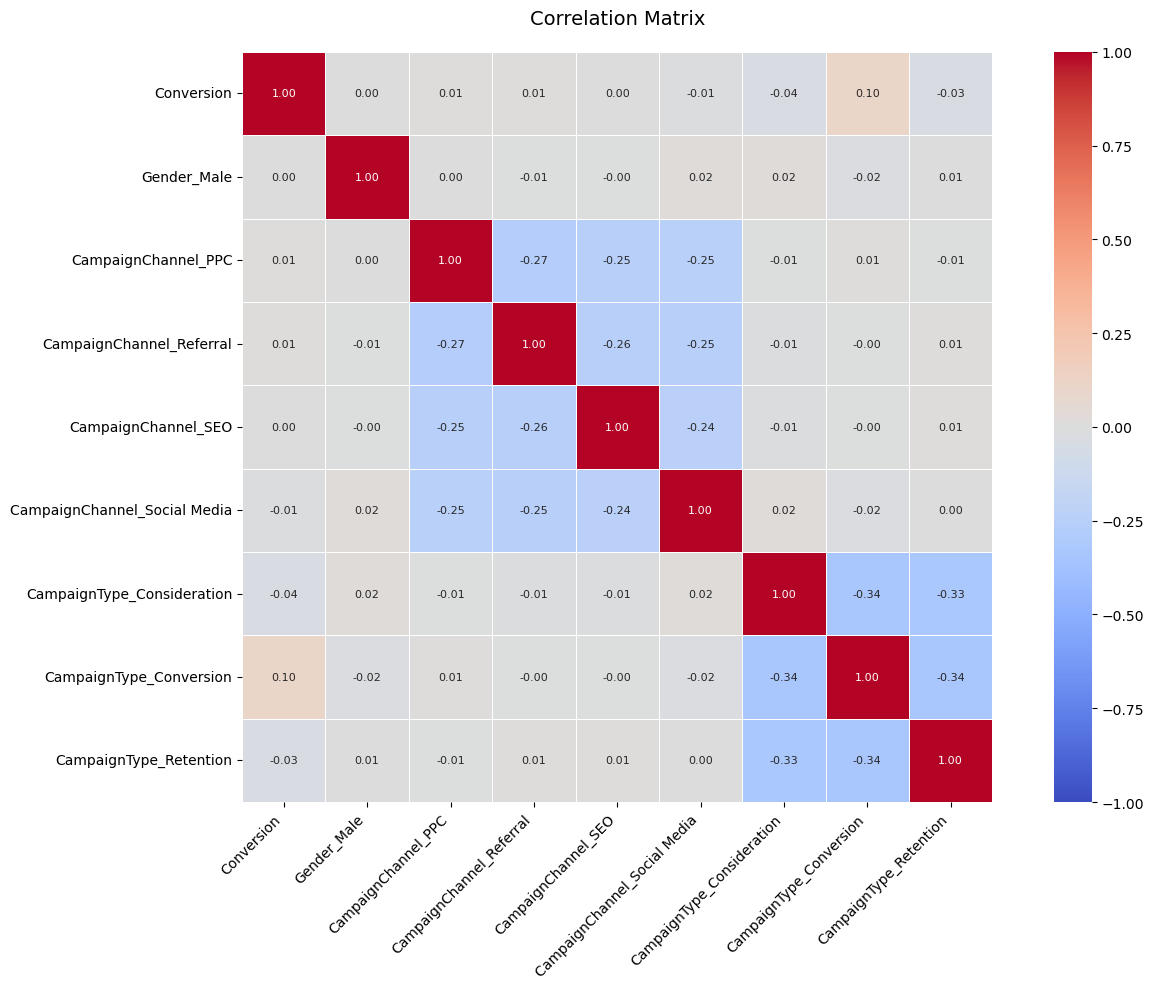

In [8]:
df_cats_only = df[string_columns + ['Conversion']]
df_encoded = pd.get_dummies(df_cats_only, drop_first=True)
cat_corr_matrix = df_encoded.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(
    cat_corr_matrix,
    annot=True,
    fmt='.2f',            
    cmap='coolwarm',
    annot_kws={'size': 8}, 
    linewidths=0.5,
    vmin=-1, vmax=1,
    square=True
)
plt.title('Correlation Matrix', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Unsurprisingly, the campaign type and channel type columns are negatively related -- the presence of one is mutually exclusive with the presence of the other. However, concerningly, I'm not finding any obvious correlations between campaign type, channel type, gender and conversion rates. There is a weak correlation between conversion and conversion campaigns -- the correlation isn't as strong as I would expect. 

Alright, shifting my thinking from overly complicated modeling to simple descriptive stats. Let's just see based flat percentages. 

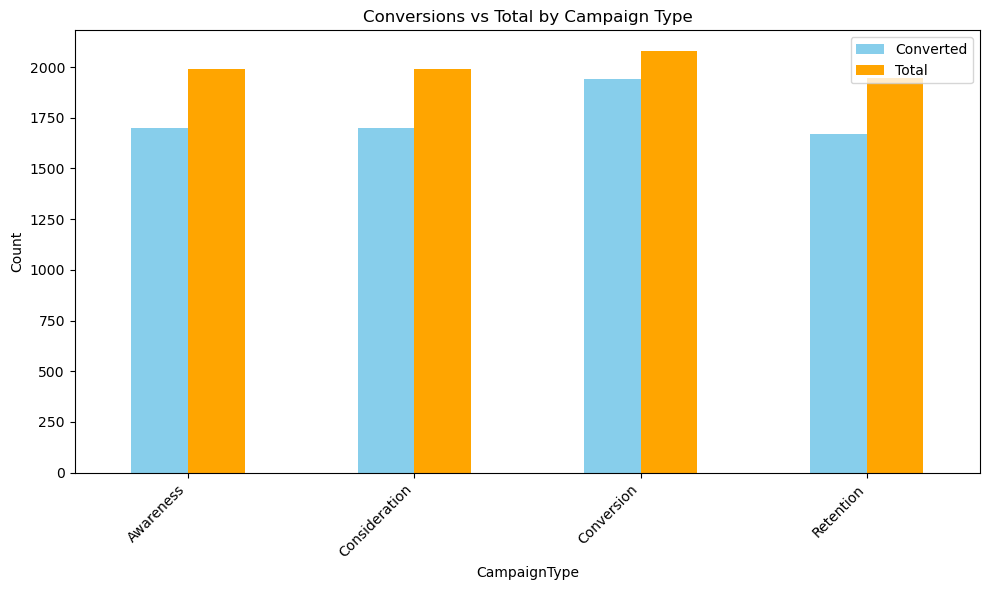

In [9]:
comparison = df.groupby('CampaignType').agg(
    Converted=('Conversion', 'sum'),
    Total=('CampaignType', 'size')
)

comparison.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'orange'])
plt.title('Conversions vs Total by Campaign Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
all_summaries = []

for cat_col in string_columns:
    grouped = df.groupby(cat_col).agg(
        Converted=('Conversion', 'sum'),
        Total=(cat_col, 'size')
    )
    grouped['Conversion Rate'] = grouped['Converted'] / grouped['Total']
    grouped = grouped.reset_index().rename(columns={cat_col: 'Category'})
    grouped.insert(0, 'Variable', cat_col)
    all_summaries.append(grouped)

summary = pd.concat(all_summaries, ignore_index=True)
summary = summary.sort_values('Conversion Rate', ascending=False)
summary

,Variable,Category,Converted,Total,Conversion Rate
9,CampaignType,Conversion,1939,2077,0.933558
4,CampaignChannel,Referral,1518,1719,0.883072
3,CampaignChannel,PPC,1461,1655,0.882779
1,Gender,Male,2772,3161,0.876938
5,CampaignChannel,SEO,1359,1550,0.876774
0,Gender,Female,4240,4839,0.876214
2,CampaignChannel,Email,1355,1557,0.870263
6,CampaignChannel,Social Media,1319,1519,0.868334
10,CampaignType,Retention,1671,1947,0.858243
8,CampaignType,Consideration,1701,1988,0.855634


Interesting for business insights, but this might not be the most valuable information for producing a predictive model. 

              precision    recall  f1-score   support

           0       0.30      0.73      0.42       198
           1       0.95      0.76      0.84      1402

    accuracy                           0.75      1600
   macro avg       0.63      0.74      0.63      1600
weighted avg       0.87      0.75      0.79      1600

ROC-AUC Score: 0.782


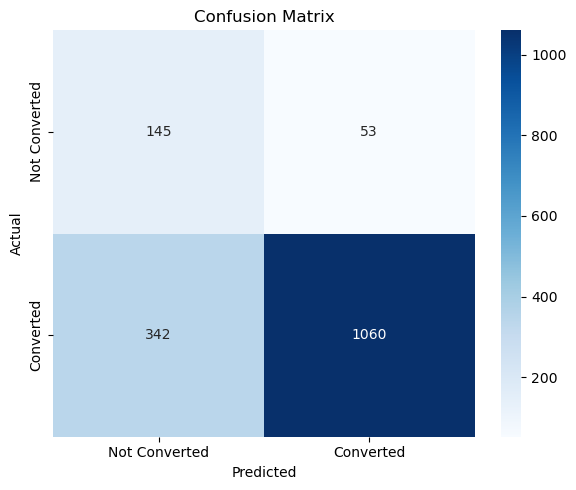

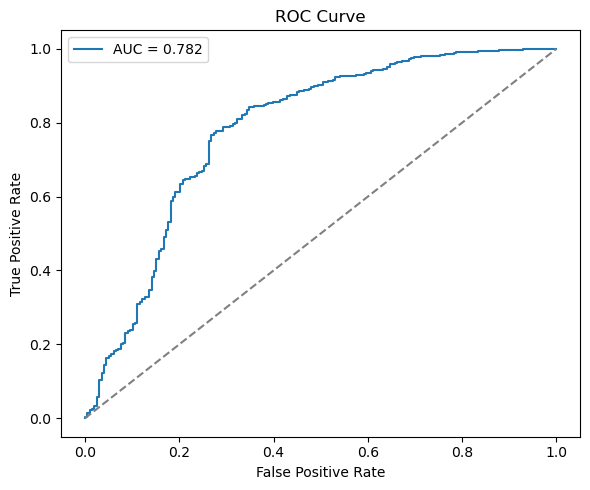

C:\Users\ryan1\AppData\Local\Temp\ipykernel_12020\4008466268.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df.head(15), x='Coefficient', y='Feature', palette='coolwarm')


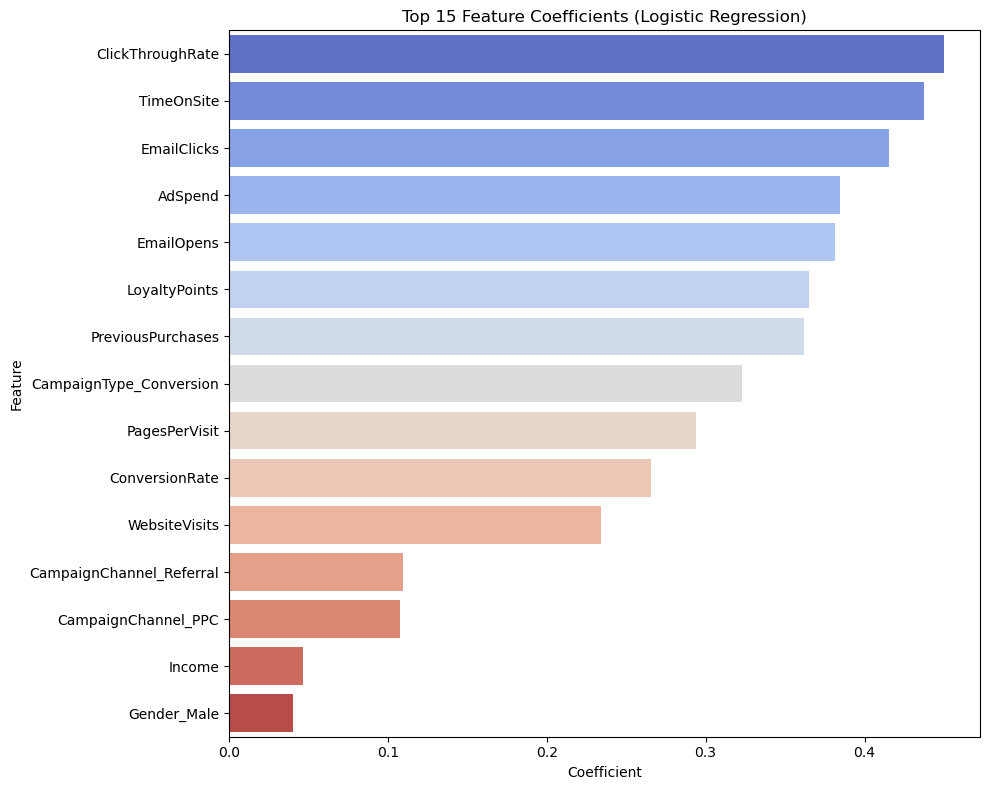

                     Feature  Coefficient
3           ClickThroughRate     0.450161
7                 TimeOnSite     0.437125
10               EmailClicks     0.415597
2                    AdSpend     0.384415
9                 EmailOpens     0.381409
12             LoyaltyPoints     0.364736
11         PreviousPurchases     0.361701
19   CampaignType_Conversion     0.322700
6              PagesPerVisit     0.293841
4             ConversionRate     0.265498
5              WebsiteVisits     0.234255
15  CampaignChannel_Referral     0.109635
14       CampaignChannel_PPC     0.107837
1                     Income     0.046843
13               Gender_Male     0.040242


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, roc_curve, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Prepare features and target ---
# Encode categoricals (drop_first avoids the redundancy issue we discussed)
df_encoded = pd.get_dummies(df, columns=string_columns, drop_first=True)

# Drop identifier columns - not real predictors, just spurious correlation risk
X = df_encoded.drop(columns=['Conversion', 'CustomerID'])  # add any other ID/leakage cols here
y = df_encoded['Conversion']

# --- 2. Train/test split (stratify keeps the ~88/12 class ratio consistent in both sets) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 3. Scale features (log reg is sensitive to feature scale) ---
# Fit scaler on TRAIN only, then apply to test - avoids data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 4. Fit logistic regression ---
# class_weight='balanced' addresses your class imbalance directly
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# --- 5. Predictions ---
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]  # probability of class 1

# --- 6. Evaluation (accuracy alone is misleading with imbalance - use full report) ---
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.3f}")

# --- 7. Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Converted', 'Converted'],
            yticklabels=['Not Converted', 'Converted'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# --- 8. ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_pred_proba):.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

# --- 9. Feature importance (coefficients) ---
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=coef_df.head(15), x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Top 15 Feature Coefficients (Logistic Regression)')
plt.tight_layout()
plt.show()

print(coef_df.head(15))